* Сгенерируем данные
* Разобъем их на кластеры с помощью AgglomerativeClustering
* Разобъем эти же данные на кластеры с помощью DBSCAN
* Определим оптимальное число кластеров в этих данных
* Применим оба алгоритма к реальному примеру

In [62]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs, make_moons, make_circles, make_classification
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# AgglomerativeClustering

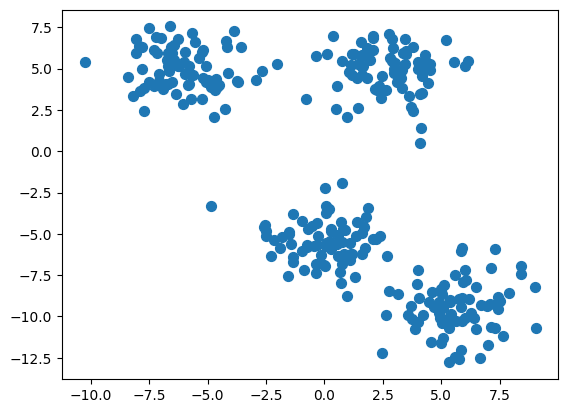

In [63]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.5, random_state=10)
plt.scatter(X[:, 0], X[:, 1], s=50);

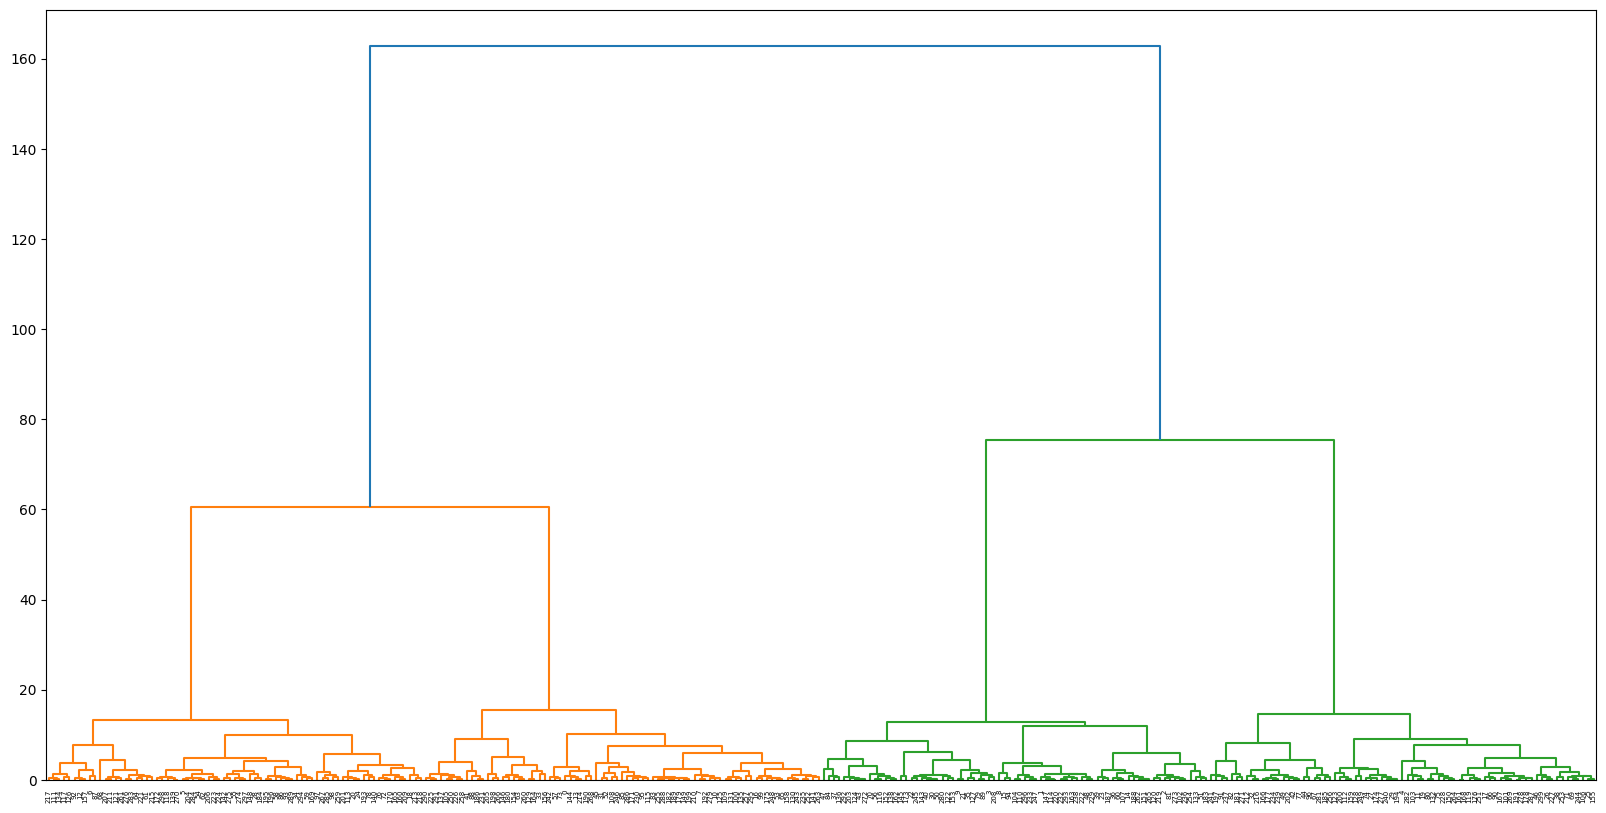

In [3]:
plt.figure(figsize=(20,10))
linkage_ = linkage(X, method='ward')
dendrogram_ = dendrogram(linkage_)

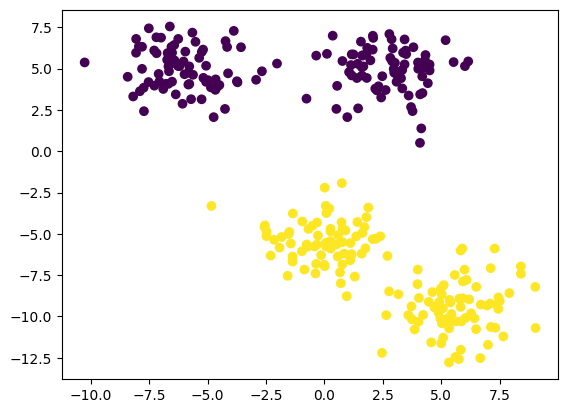

In [4]:
agg = AgglomerativeClustering(n_clusters=2).fit(X)
labels = agg.labels_

plt.scatter(X[:,0], X[:,1], c=labels);

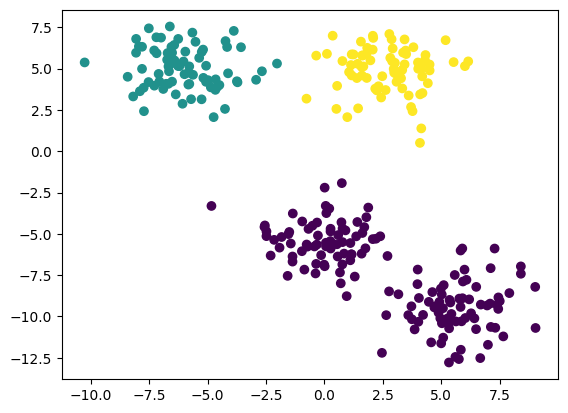

In [5]:
agg = AgglomerativeClustering(n_clusters=3).fit(X)
labels = agg.labels_

plt.scatter(X[:,0], X[:,1], c=labels);

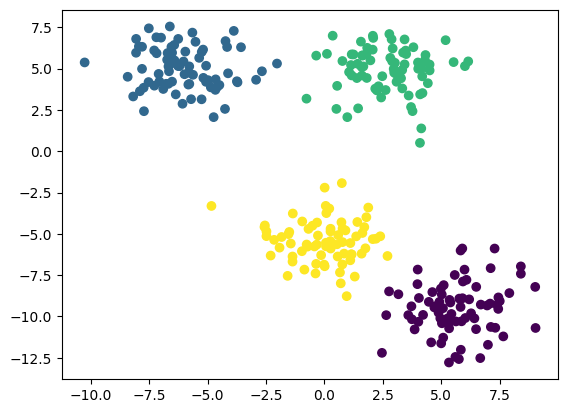

In [6]:
agg = AgglomerativeClustering(n_clusters=4).fit(X)
labels = agg.labels_

plt.scatter(X[:,0], X[:,1], c=labels);

### Cилуэтный коэффициент

In [7]:
silhouette = []
for i in tqdm(range(2,11)):
    agg = AgglomerativeClustering(n_clusters=i).fit(X)
    labels = agg.labels_
    score = silhouette_score(X, labels)
    silhouette.append(score)

  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 317.02it/s]


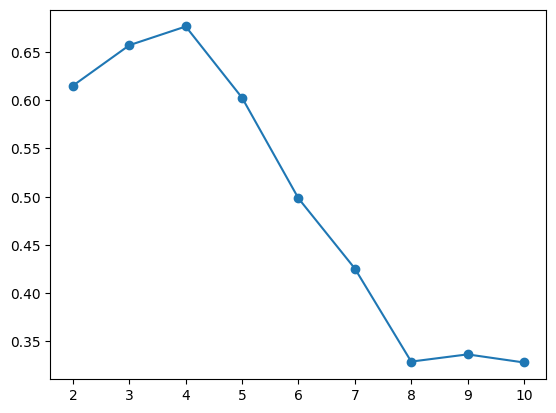

In [8]:
plt.plot(range(2,11), silhouette, marker='o');

## Сложные формы данных

In [9]:
def agg_clustering(n_clusters, X, linkage = 'single'):
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage = linkage).fit(X)
    labels = agg.labels_

    plt.scatter(X[:,0], X[:,1], c=labels)
    plt.title(str(n_clusters)+' кластера')
    plt.show();

In [10]:
AgglomerativeClustering?

Init signature:
AgglomerativeClustering(
    n_clusters=2,
    *,
    metric='euclidean',
    memory=None,
    connectivity=None,
    compute_full_tree='auto',
    linkage='ward',
    distance_threshold=None,
    compute_distances=False,
)
Docstring:     
Agglomerative Clustering.

Recursively merges pair of clusters of sample data; uses linkage distance.

Read more in the :ref:`User Guide <hierarchical_clustering>`.

Parameters
----------
n_clusters : int or None, default=2
    The number of clusters to find. It must be ``None`` if
    ``distance_threshold`` is not ``None``.

metric : str or callable, default="euclidean"
    Metric used to compute the linkage. Can be "euclidean", "l1", "l2",
    "manhattan", "cosine", or "precomputed". If linkage is "ward", only
    "euclidean" is accepted. If "precomputed", a distance matrix is needed
    as input for the fit method.

    .. versionadded:: 1.2

    .. deprecated:: 1.4
       `metric=None` is deprecated in 1.4 and will be removed in 1

### Two moons

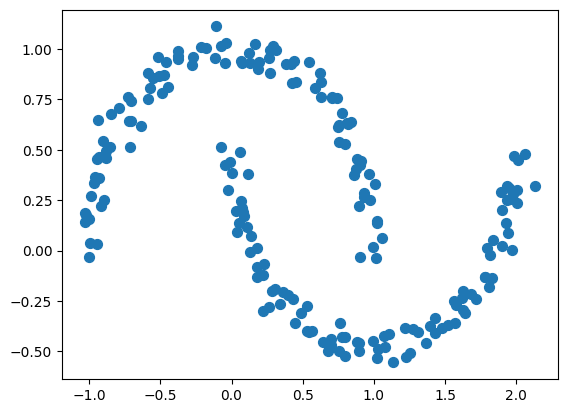

In [11]:
X, y = make_moons(200, noise=.05, random_state=10)
plt.scatter(X[:, 0], X[:, 1], s=50);

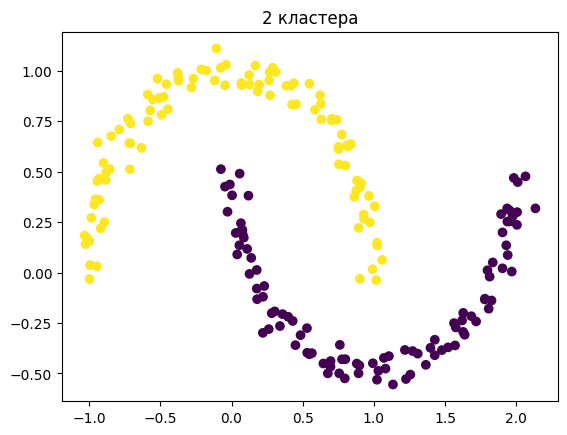

In [12]:
agg_clustering(2,X, 'single')

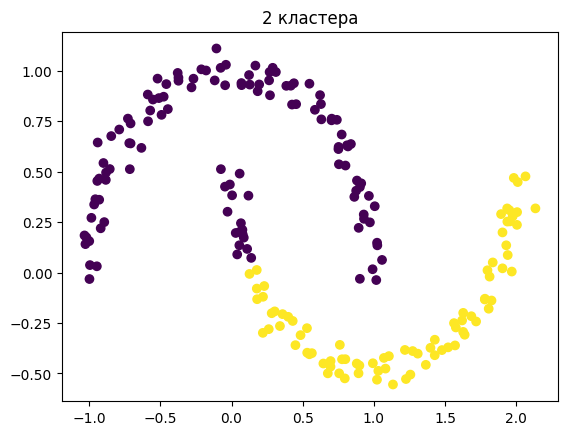

In [13]:
agg_clustering(2,X, 'ward')

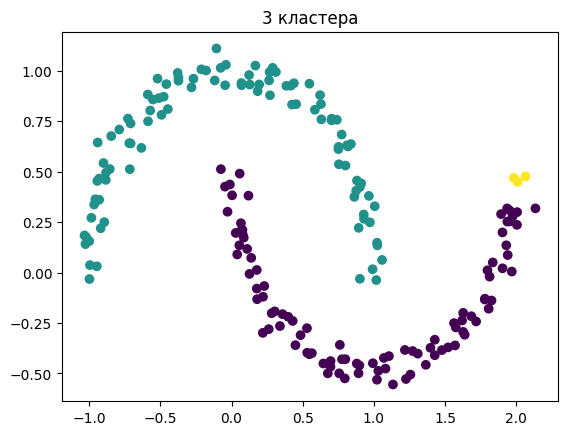

In [14]:
agg_clustering(3,X)

In [15]:
silhouette = []
for i in tqdm(range(2,11)):
    agg = AgglomerativeClustering(n_clusters=i, linkage = 'single').fit(X)
    labels = agg.labels_
    score = silhouette_score(X, labels)
    silhouette.append(score)

100%|██████████| 9/9 [00:00<00:00, 627.36it/s]


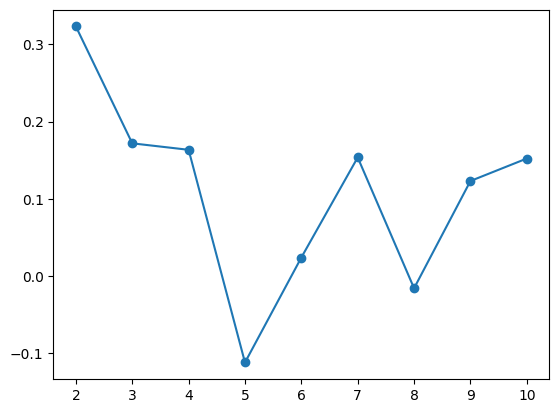

In [16]:
plt.plot(range(2,11), silhouette, marker='o');

In [17]:
silhouette = []
for i in tqdm(range(2,11)):
    agg = AgglomerativeClustering(n_clusters=i, linkage = 'ward').fit(X)
    labels = agg.labels_
    score = silhouette_score(X, labels)
    silhouette.append(score)

100%|██████████| 9/9 [00:00<00:00, 181.98it/s]


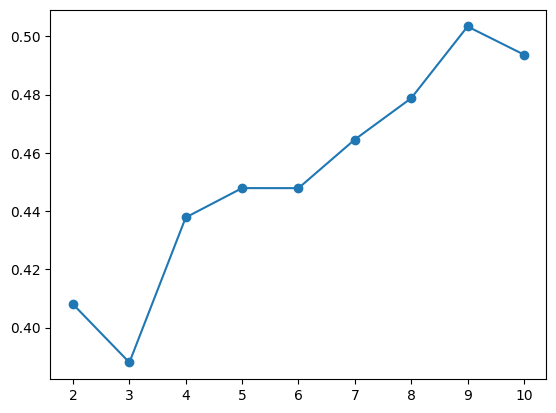

In [18]:
plt.plot(range(2,11), silhouette, marker='o');

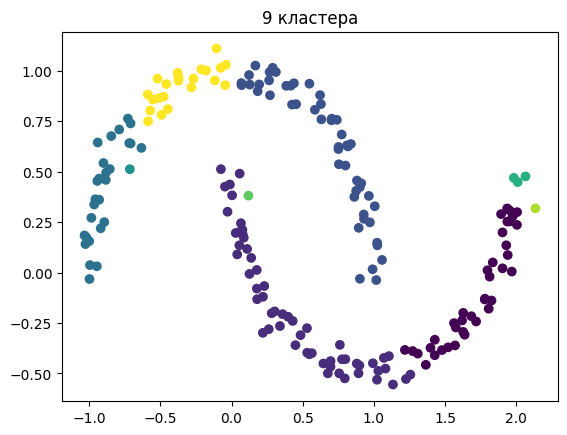

In [19]:
agg_clustering(9,X)

### Circles

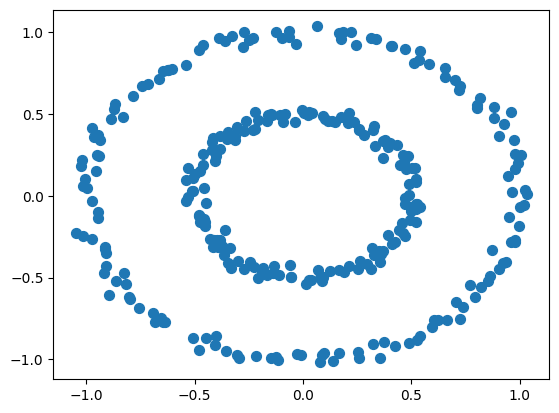

In [20]:
X, y = make_circles(n_samples=300, noise=0.03, random_state=10, factor=0.5)
plt.scatter(X[:, 0], X[:, 1], s=50);

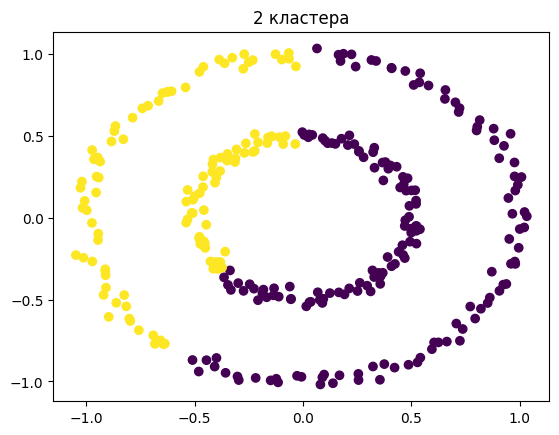

In [21]:
agg_clustering(2,X, 'ward')

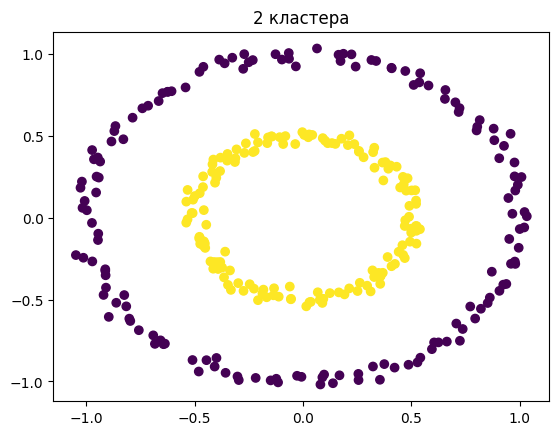

In [22]:
agg_clustering(2,X, 'single')

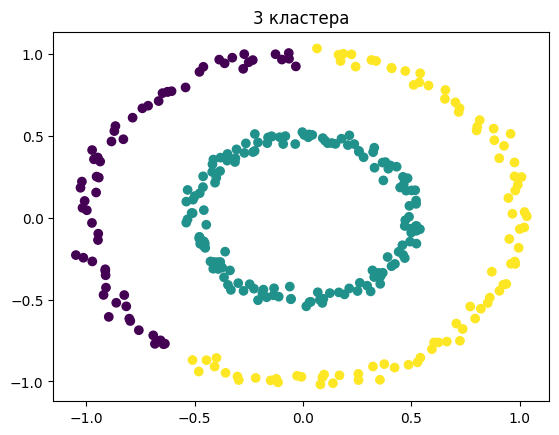

In [23]:
agg_clustering(3,X, 'single')

In [24]:
silhouette = []
for i in tqdm(range(2,21)):
    agg = AgglomerativeClustering(n_clusters=i, linkage = 'single').fit(X)
    labels = agg.labels_
    score = silhouette_score(X, labels)
    silhouette.append(score)

100%|██████████| 19/19 [00:00<00:00, 418.10it/s]


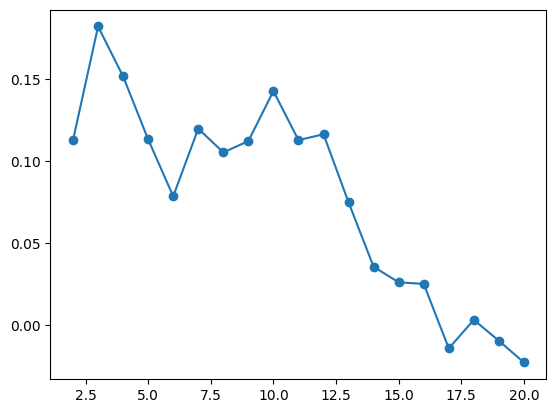

In [25]:
plt.plot(range(2,21), silhouette, marker='o');

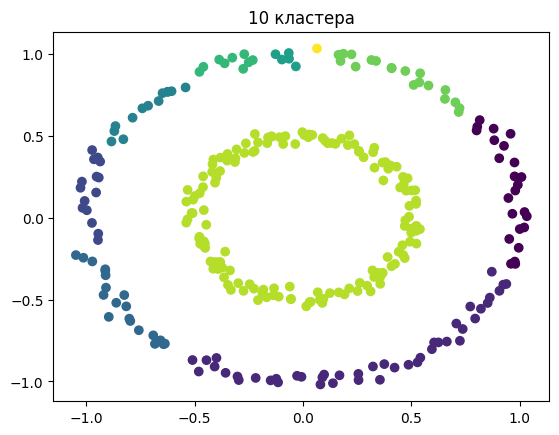

In [26]:
agg_clustering(10,X)

### Anisotropicly Distributed

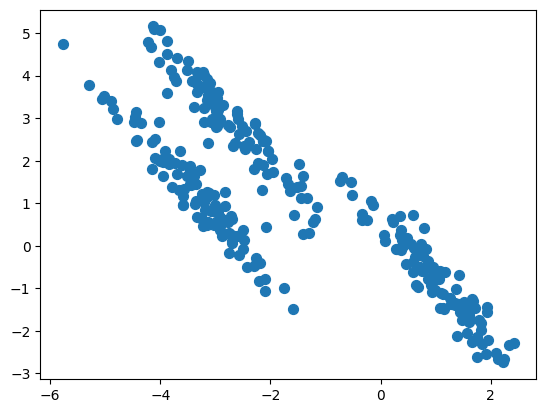

In [27]:
X, y_true = make_blobs(n_samples=300, centers=3, random_state=170)
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X = np.dot(X, transformation)
plt.scatter(X[:, 0], X[:, 1], s=50);

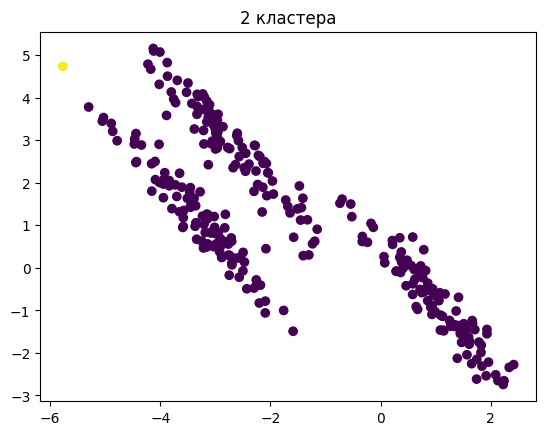

In [28]:
agg_clustering(2,X)

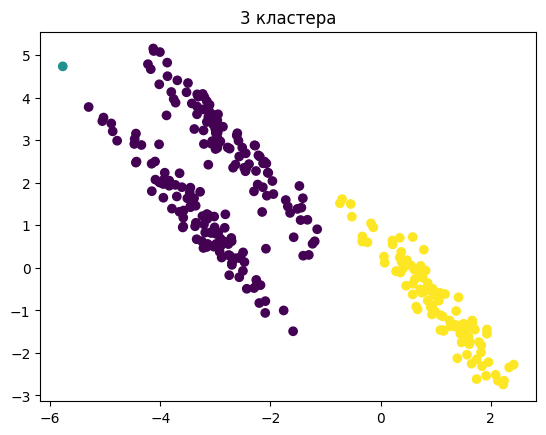

In [29]:
agg_clustering(3,X)

In [30]:
silhouette = []
for i in tqdm(range(2,11)):
    agg = AgglomerativeClustering(n_clusters=i).fit(X)
    labels = agg.labels_
    score = silhouette_score(X, labels)
    silhouette.append(score)

100%|██████████| 9/9 [00:00<00:00, 363.92it/s]


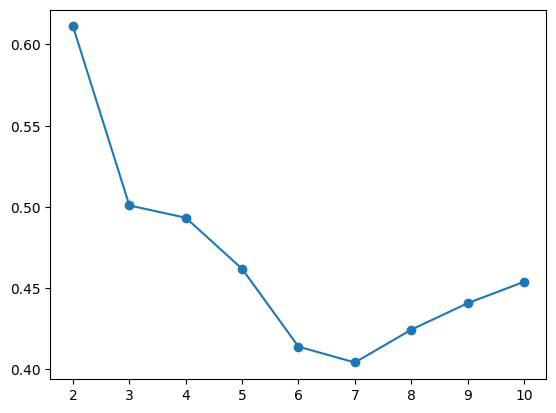

In [31]:
plt.plot(range(2,11), silhouette, marker='o');

# DBSCAN

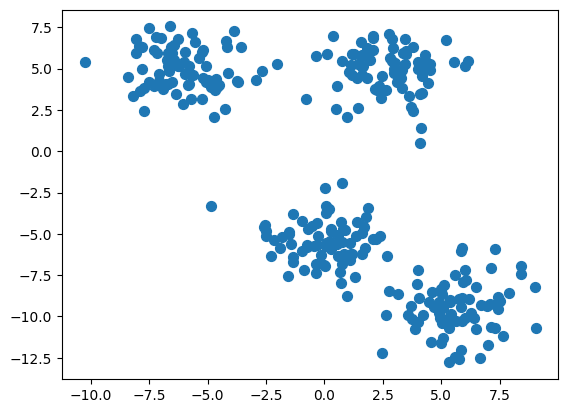

In [32]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.5, random_state=10)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [33]:
dbscan = DBSCAN().fit(X)
labels = dbscan.labels_

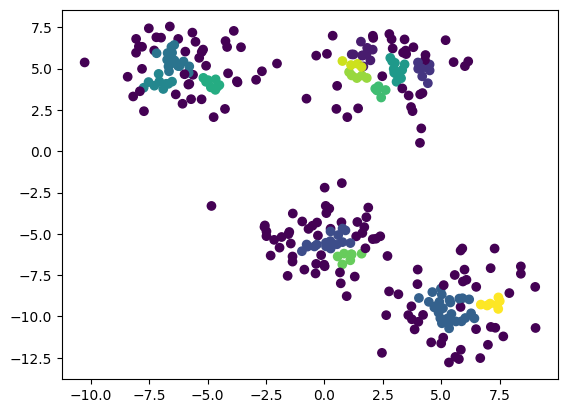

In [34]:
plt.scatter(X[:,0], X[:,1], c=labels);

In [35]:
np.unique(labels)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [36]:
uniq_labels = np.unique(labels)
uniq_labels

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [37]:
n_clusters = len(uniq_labels[uniq_labels != -1])
n_clusters

13

кластеров: 13


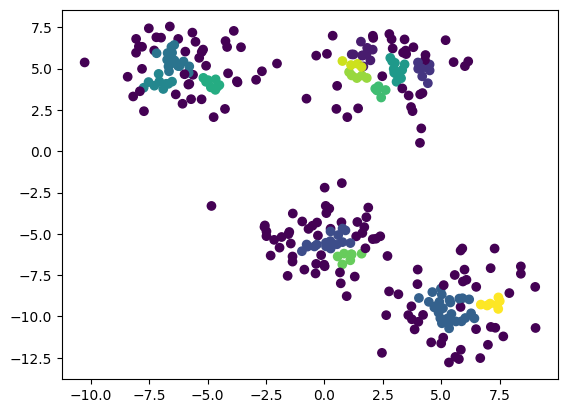

In [38]:
dbscan = DBSCAN().fit(X)
labels = dbscan.labels_
uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')
plt.scatter(X[:,0], X[:,1], c=labels);

кластеров: 4


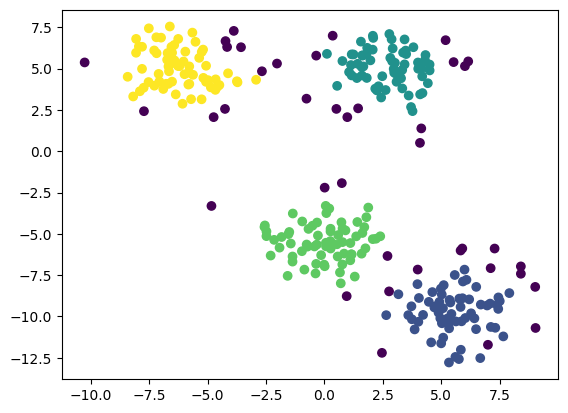

In [39]:
dbscan = DBSCAN(eps=1, min_samples=5).fit(X)
labels = dbscan.labels_
uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')
plt.scatter(X[:,0], X[:,1], c=labels);

кластеров: 4


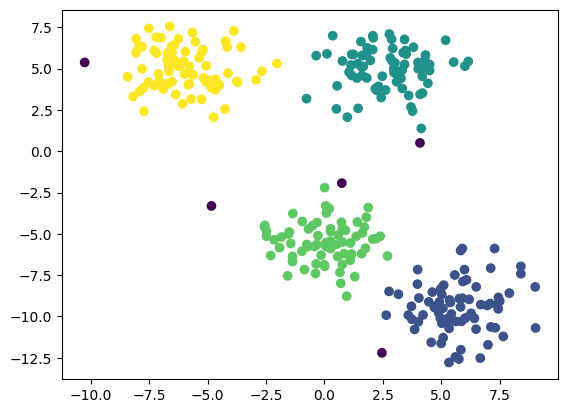

In [40]:
dbscan = DBSCAN(eps=1.5, min_samples=5).fit(X)
labels = dbscan.labels_
uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')
plt.scatter(X[:,0], X[:,1], c=labels);

In [41]:
np.unique(labels)[np.unique(labels) != -1]

array([0, 1, 2, 3])

In [42]:
np.delete(np.unique(labels), -1)

array([-1,  0,  1,  2])

### Cилуэтный коэффициент

In [43]:
silhouette = []
clusters = []
eps_range = np.arange(0.1,2,0.1)
for i in tqdm(eps_range):
    dbscan = DBSCAN(eps=i).fit(X)
    labels = dbscan.labels_
    uniq_labels = np.unique(labels)
    n_clusters = len(uniq_labels[uniq_labels != -1])
    if n_clusters > 1:
        score = silhouette_score(X, labels)
    else:
        score = 0
    silhouette.append(score)
    clusters.append(n_clusters)

100%|██████████| 19/19 [00:00<00:00, 455.71it/s]


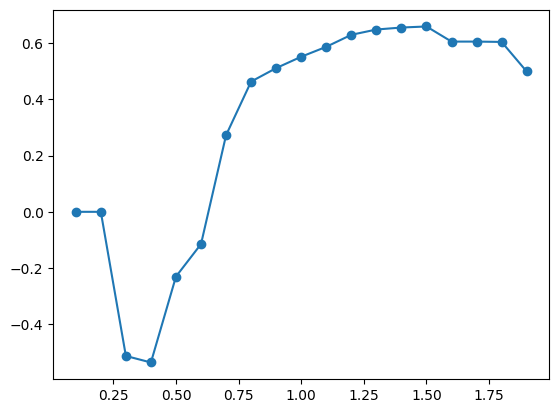

In [44]:
plt.plot(eps_range, silhouette, marker='o');

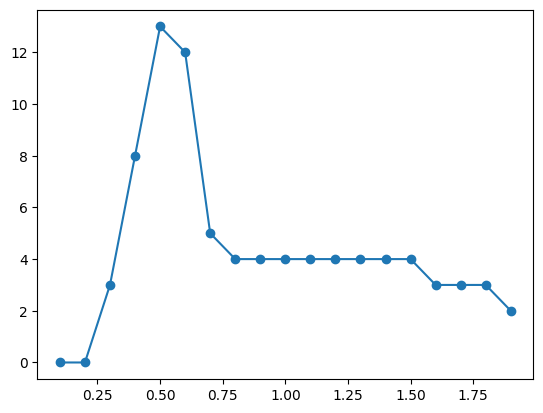

In [45]:
plt.plot(eps_range, clusters, marker='o');

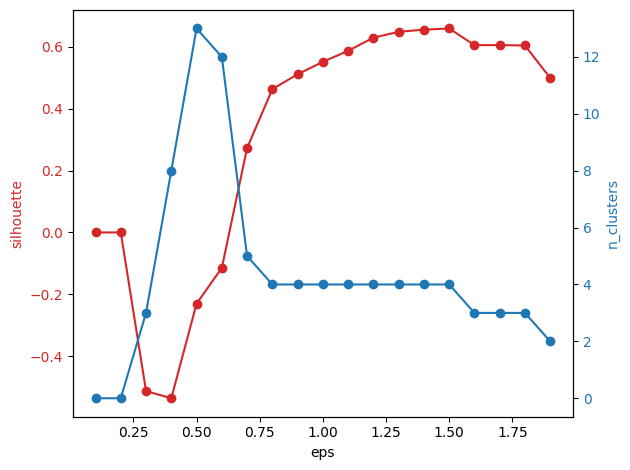

In [46]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.plot(eps_range, silhouette, marker='o', color=color)
ax1.set_xlabel('eps')
ax1.set_ylabel('silhouette', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.plot(eps_range, clusters, marker='o', color=color)
ax2.set_ylabel('n_clusters', color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

## Сложные формы данных

In [47]:
def dbscan_clustering(eps_range, X):
    eps_range = eps_range
    silhouette = []
    clusters = []
    for i in tqdm(eps_range):
        dbscan = DBSCAN(eps=i).fit(X)
        labels = dbscan.labels_
        uniq_labels = np.unique(labels)
        n_clusters = len(uniq_labels[uniq_labels != -1])
        if n_clusters > 1:
            score = silhouette_score(X, labels)
        else:
            score = 0
        silhouette.append(score)
        clusters.append(n_clusters)

    fig, ax1 = plt.subplots()

    color = 'tab:red'
    ax1.plot(eps_range, silhouette, marker='o', color=color)
    ax1.set_xlabel('eps')
    ax1.set_ylabel('silhouette', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color = 'tab:blue'
    ax2.plot(eps_range, clusters, marker='o', color=color)
    ax2.set_ylabel('n_clusters', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()

### Two moons

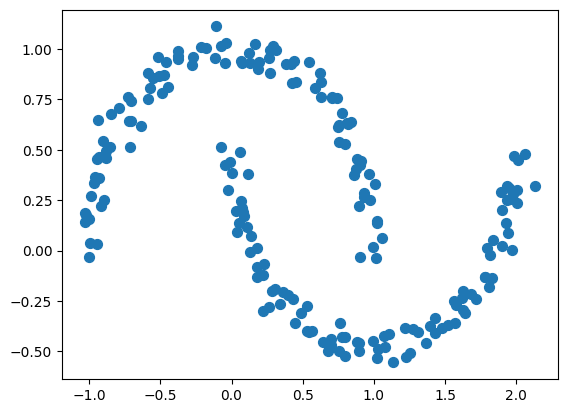

In [48]:
X, y = make_moons(200, noise=.05, random_state=10)
plt.scatter(X[:, 0], X[:, 1], s=50);

100%|██████████| 19/19 [00:00<00:00, 833.52it/s]


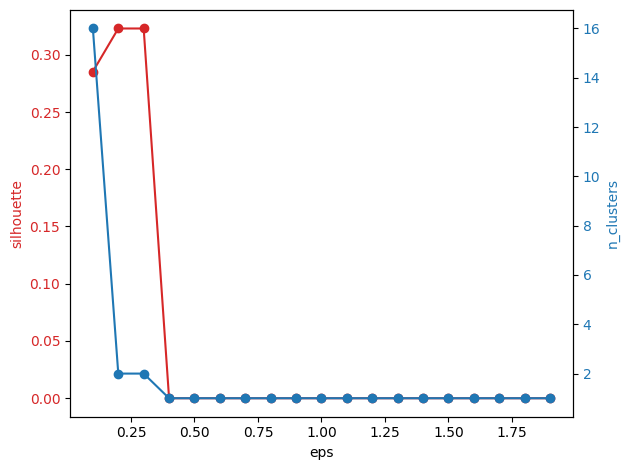

In [49]:
#eps_range = np.arange(0.01,0.3,0.05)
eps_range = np.arange(0.1,2,0.1)
dbscan_clustering(eps_range, X)

100%|██████████| 6/6 [00:00<00:00, 576.99it/s]


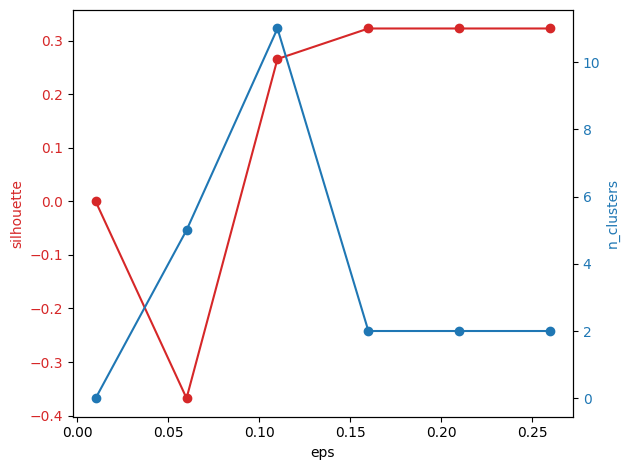

In [50]:
eps_range = np.arange(0.01,0.3,0.05)
dbscan_clustering(eps_range, X)

кластеров: 2


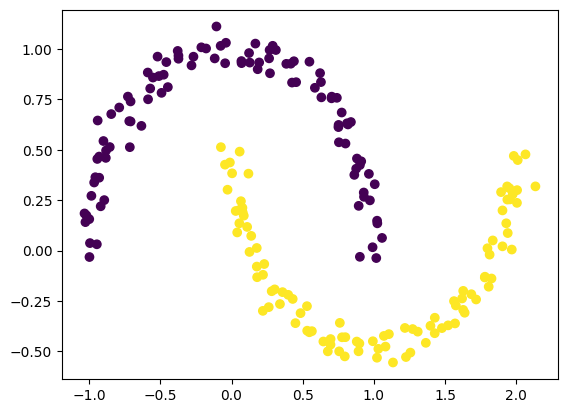

In [51]:
dbscan = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = dbscan.labels_
uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')
plt.scatter(X[:,0], X[:,1], c=labels);

### Circles

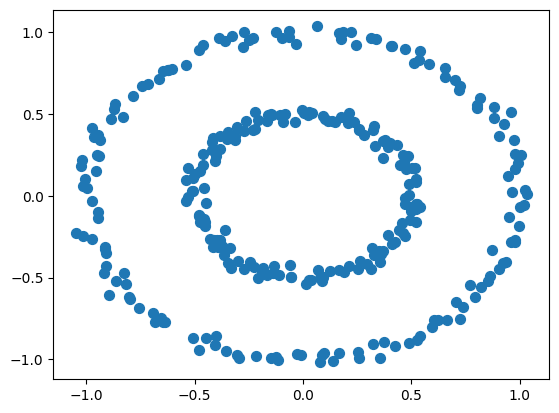

In [52]:
X, y = make_circles(n_samples=300, noise=0.03, random_state=10, factor=0.5)
plt.scatter(X[:, 0], X[:, 1], s=50);

100%|██████████| 6/6 [00:00<00:00, 418.56it/s]


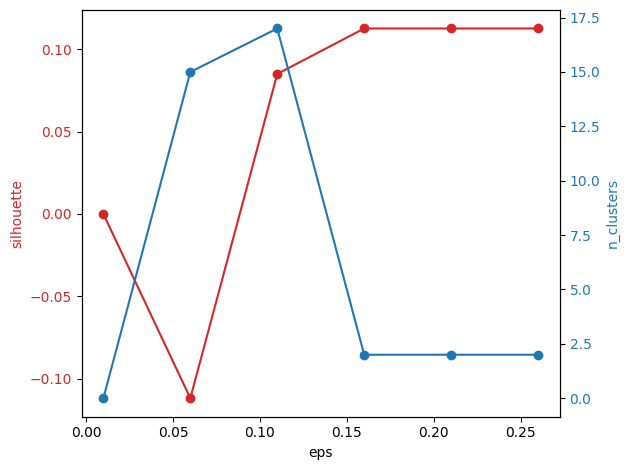

In [53]:
eps_range = np.arange(0.01,0.3,0.05)
dbscan_clustering(eps_range, X)

кластеров: 2


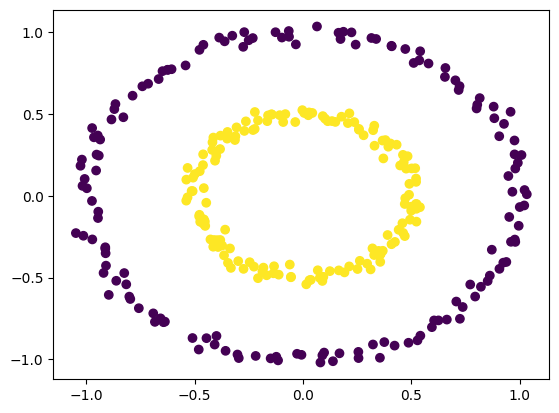

In [54]:
dbscan = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = dbscan.labels_
uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')
plt.scatter(X[:,0], X[:,1], c=labels);

### Anisotropicly Distributed

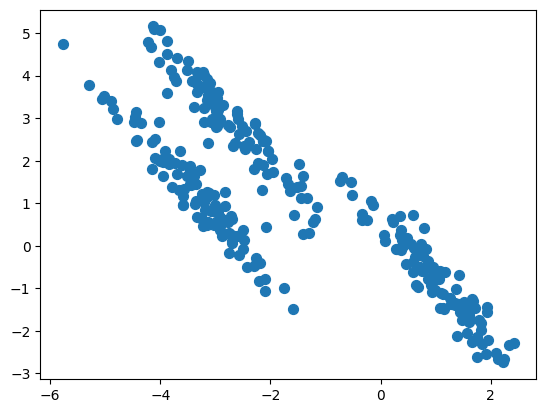

In [55]:
X, y_true = make_blobs(n_samples=300, centers=3, random_state=170)
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X = np.dot(X, transformation)
plt.scatter(X[:, 0], X[:, 1], s=50);

100%|██████████| 10/10 [00:00<00:00, 514.24it/s]


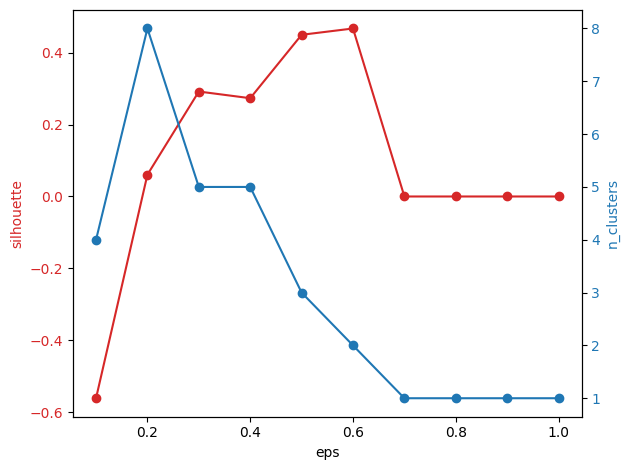

In [56]:
eps_range = np.arange(0.1,1.1,0.1)
dbscan_clustering(eps_range, X)

кластеров: 2


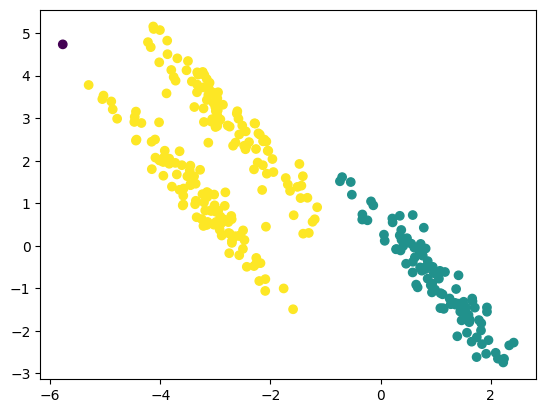

In [57]:
dbscan = DBSCAN(eps=0.6, min_samples=5).fit(X)
labels = dbscan.labels_
uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')
plt.scatter(X[:,0], X[:,1], c=labels);

кластеров: 3


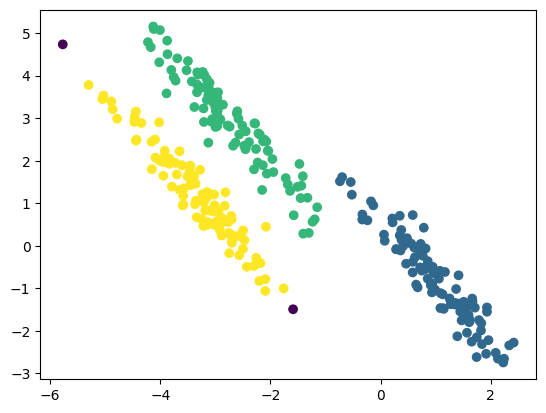

In [58]:
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X)
labels = dbscan.labels_
uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')
plt.scatter(X[:,0], X[:,1], c=labels);

кластеров: 1


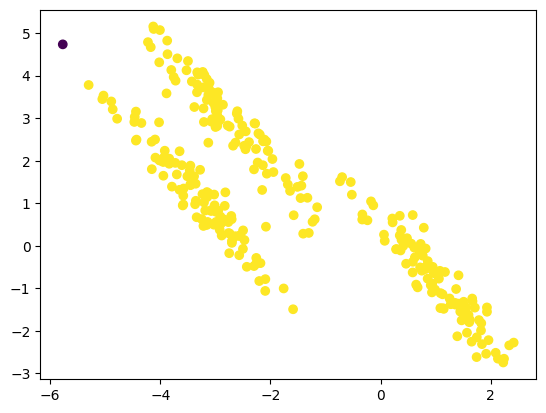

In [59]:
dbscan = DBSCAN(eps=0.8, min_samples=5).fit(X)
labels = dbscan.labels_
uniq_labels = np.unique(labels)
n_clusters = len(uniq_labels[uniq_labels != -1])
print(f'кластеров: {n_clusters}')
plt.scatter(X[:,0], X[:,1], c=labels);

# Кластеризация на реальных данных

The World Happiness Report is a landmark survey of the state of global happiness. The first report was published in 2012, the second in 2013, the third in 2015, and the fourth in the 2016 Update. The World Happiness 2017, which ranks 155 countries by their happiness levels, was released at the United Nations at an event celebrating International Day of Happiness on March 20th. The report continues to gain global recognition as governments, organizations and civil society increasingly use happiness indicators to inform their policy-making decisions. Leading experts across fields – economics, psychology, survey analysis, national statistics, health, public policy and more – describe how measurements of well-being can be used effectively to assess the progress of nations. The reports review the state of happiness in the world today and show how the new science of happiness explains personal and national variations in happiness.

Обзор о мировом счастье - это исследование состояния глобального счастья.

[Соревнование Kaggle](https://www.kaggle.com/unsdsn/world-happiness)

In [60]:
!wget -O data.csv https://drive.usercontent.google.com/download?id=1b6bK8V-2fKfKQ8z8zqYQbkjRasUaPFiZ&export=download&authuser=0&confirm=t&uuid=09175432-4e29-4265-98b2-03b28c9212c5&at=AO7h07eejM3soJYP_v4aDNZKJhyf:1725021024305

zsh:1: parse error near `&'


In [61]:
data = pd.read_csv('data.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'

In [ ]:
data.shape

(156, 9)

In [ ]:
data.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [ ]:
data['Overall rank'].nunique()

156

In [ ]:
data.drop('Overall rank', axis=1, inplace=True)

In [ ]:
data['Country or region'].nunique()

156

In [ ]:
country = data['Country or region']

In [ ]:
data.drop('Country or region', axis=1, inplace=True)

In [ ]:
data.describe()

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


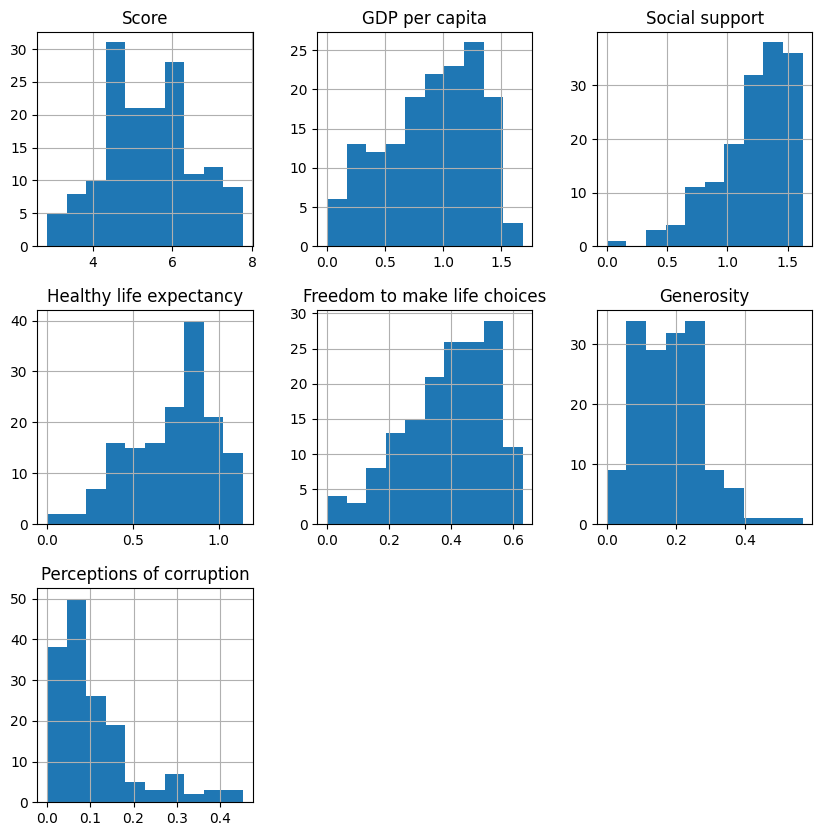

In [ ]:
data.hist(figsize=(10,10));

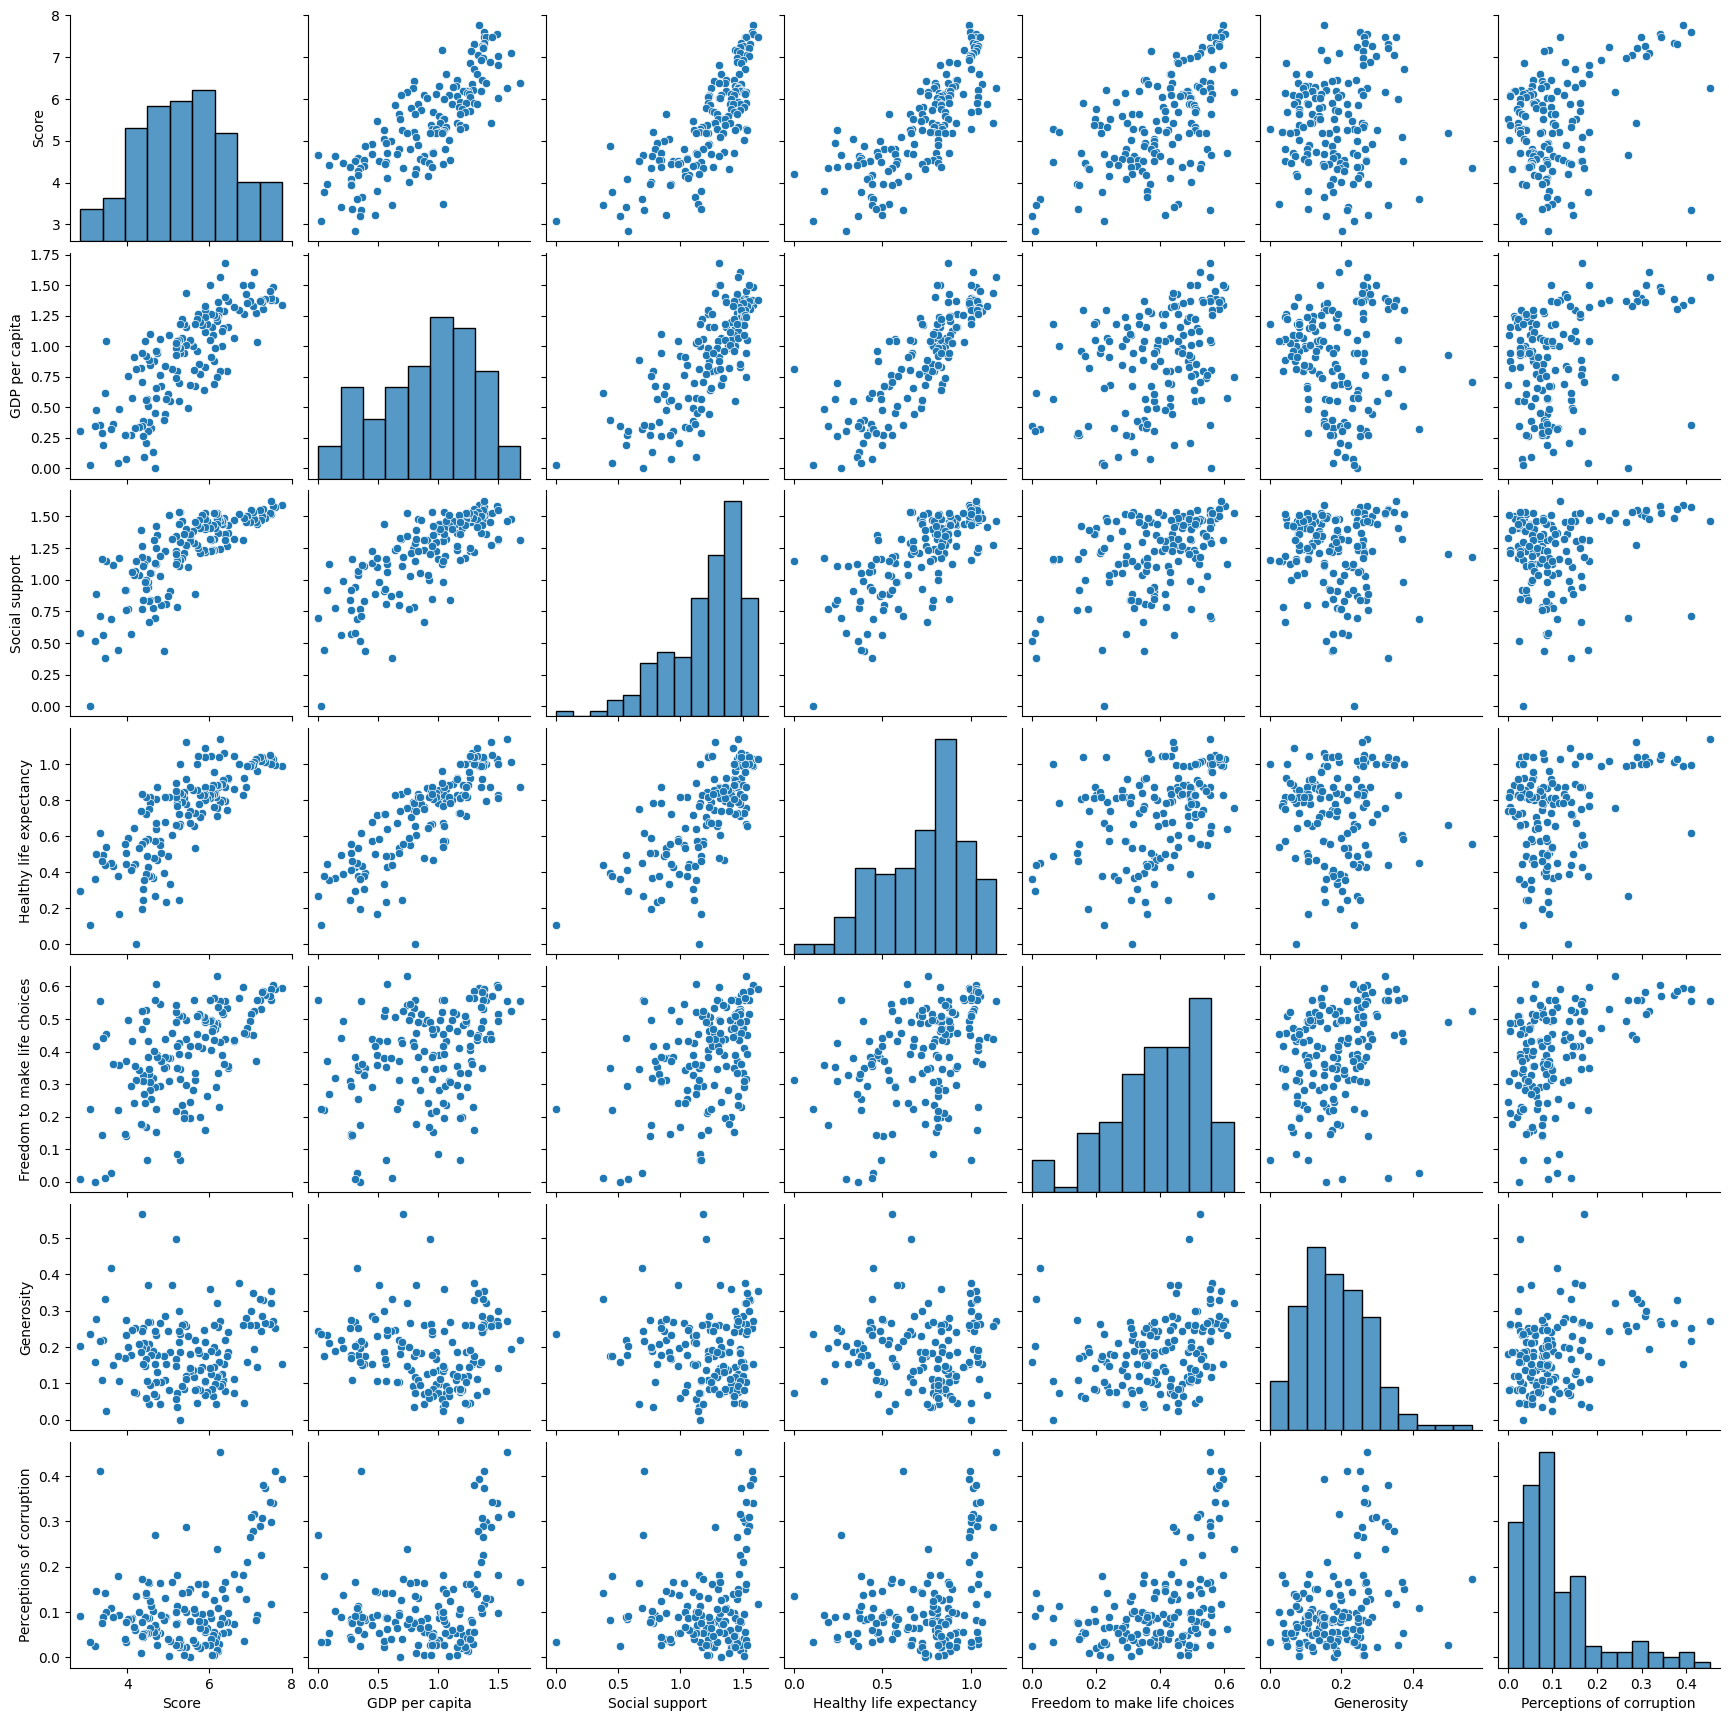

In [ ]:
sns.pairplot(data);

## 1. Корреляция

In [ ]:
corr = data.corr()

In [ ]:
mask = np.triu(np.ones_like(corr, dtype=bool))

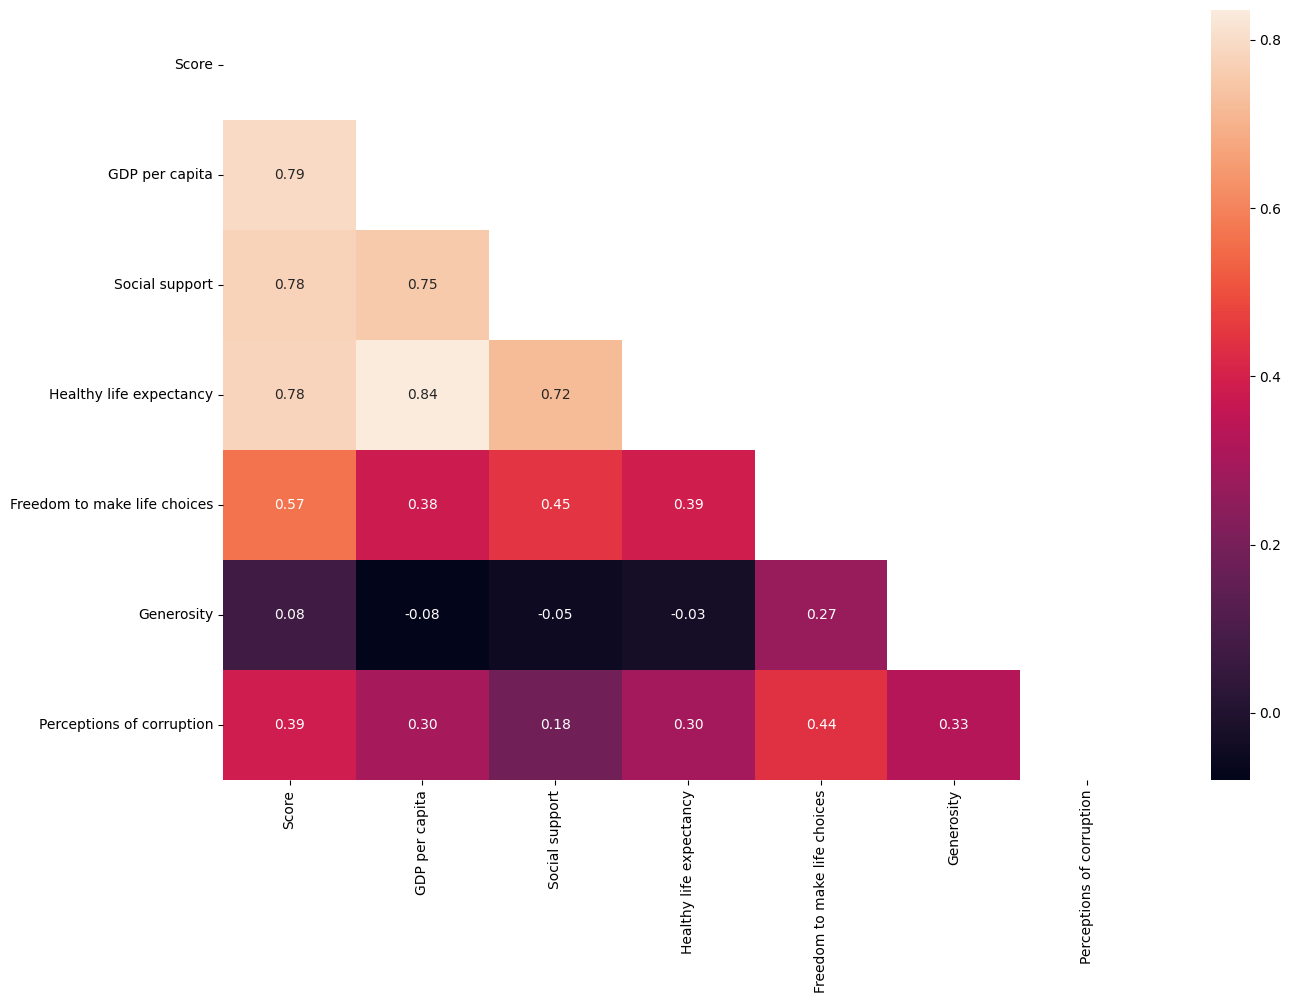

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f');

# 2. Нормализация

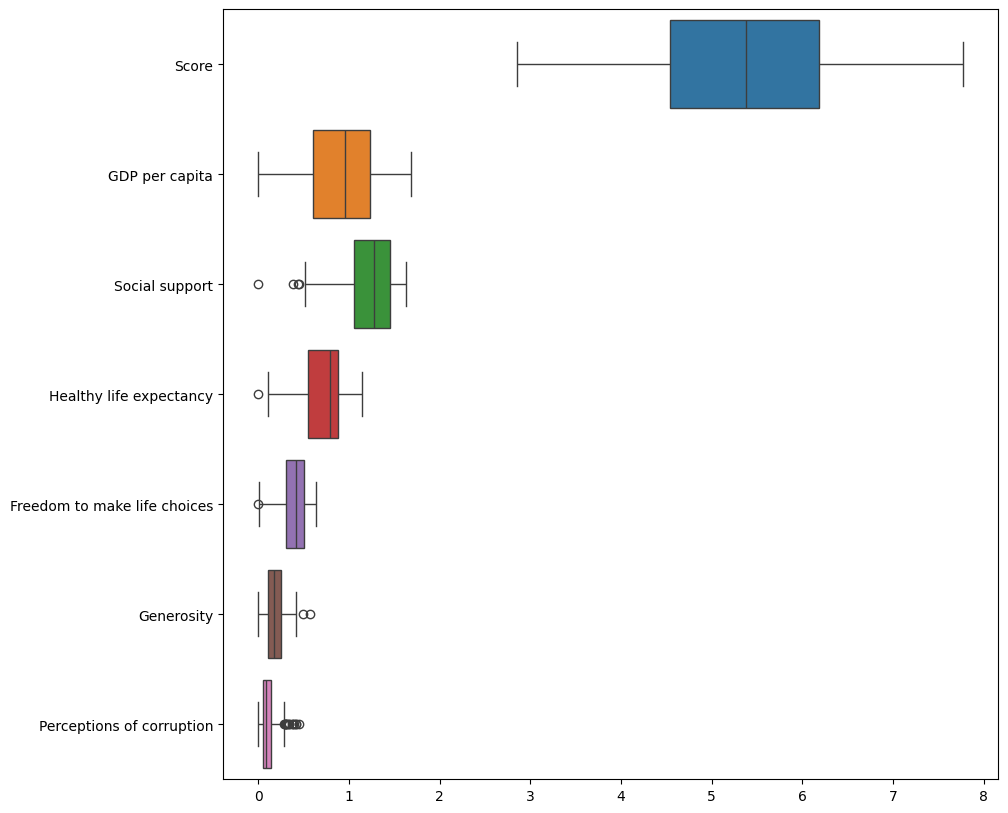

In [ ]:
plt.figure(figsize=(10,10))
sns.boxplot(data=data, orient='h');

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
X_scaled = scaler.fit_transform(data)

In [ ]:
data_scaled = pd.DataFrame(X_scaled, columns=data.columns)

In [ ]:
data_scaled.head()

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1.000000,0.795724,0.977217,0.864154,0.944532,0.270318,0.867550
1,0.965622,0.821259,0.968596,0.872918,0.938193,0.445230,0.905077
2,0.956265,0.883610,0.974138,0.900964,0.955626,0.478799,0.752759
3,0.944060,0.819477,1.000000,0.899211,0.936609,0.625442,0.260486
4,0.942840,0.828979,0.937192,0.875548,0.882726,0.568905,0.657837


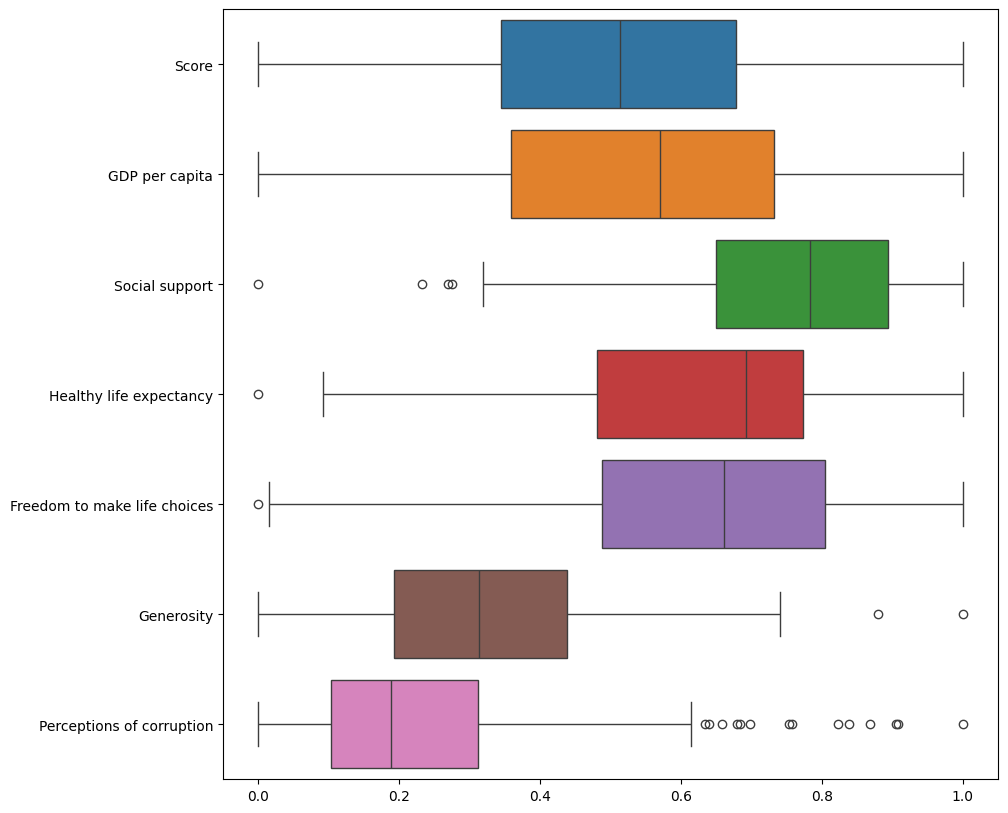

In [ ]:
plt.figure(figsize=(10,10))
sns.boxplot(data=data_scaled, orient='h');

# 3. Снижение размерности для визуализации

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(n_components=2, random_state=10)

In [ ]:
X_scaled.shape

(156, 7)

In [ ]:
X_tsne = tsne.fit_transform(X_scaled)

In [ ]:
X_tsne.shape

(156, 2)

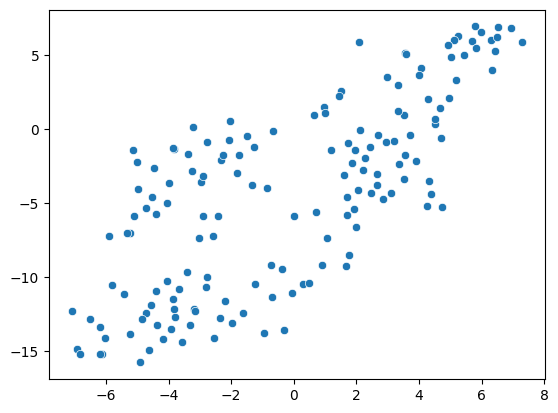

In [ ]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1]);

# 4. Кластеризация

## 4.1 AgglomerativeClustering

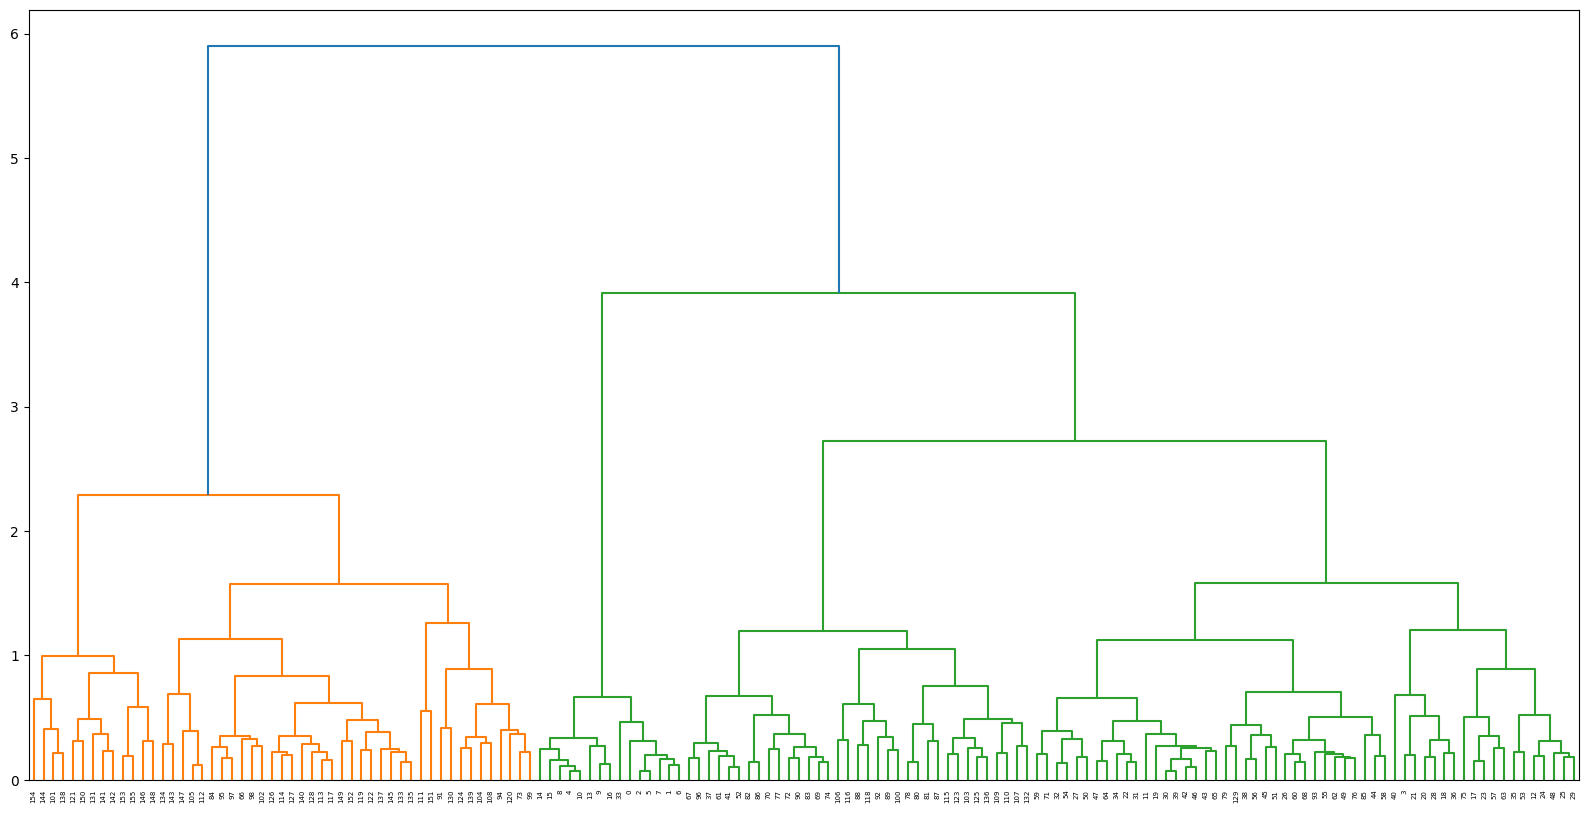

In [ ]:
plt.figure(figsize=(20,10))
linkage_ = linkage(X_scaled, method='ward')
dendrogram_ = dendrogram(linkage_)

In [ ]:
silhouette = []
for i in tqdm(range(2,11)):
    agg = AgglomerativeClustering(n_clusters=i).fit(X_scaled)
    labels = agg.labels_
    score = silhouette_score(X_scaled, labels)
    silhouette.append(score)

100%|██████████| 9/9 [00:00<00:00, 141.60it/s]


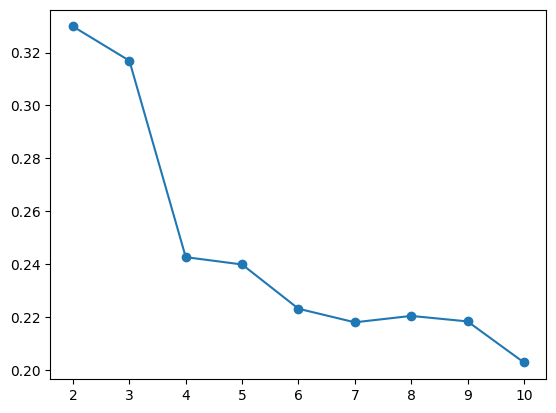

In [ ]:
plt.plot(range(2,11), silhouette, marker='o');

In [ ]:
agg = AgglomerativeClustering(n_clusters=3).fit(X_scaled)
labels = agg.labels_

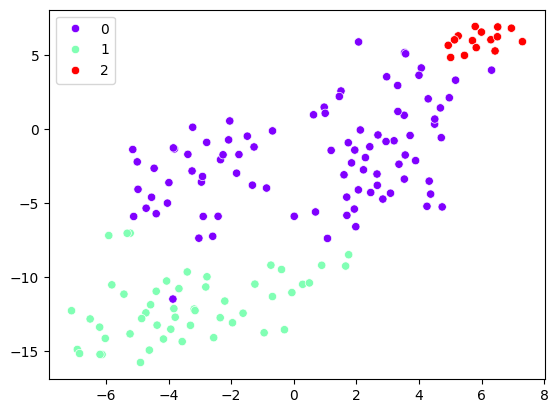

In [ ]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='rainbow');

In [ ]:
data['labels'] = labels

In [ ]:
data['labels'].value_counts(normalize=True)

,proportion
labels,
0,0.576923
1,0.326923
2,0.096154


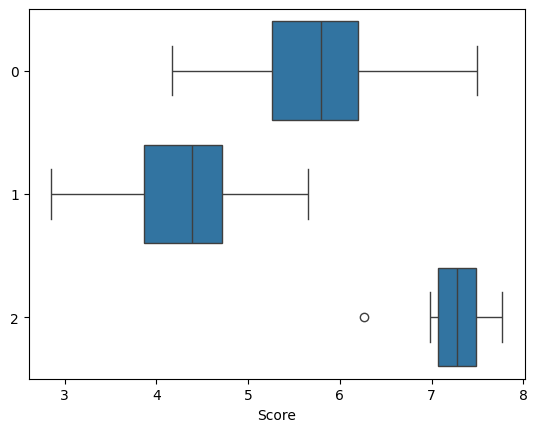

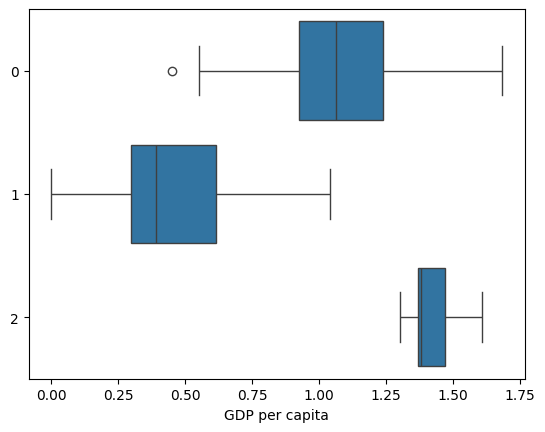

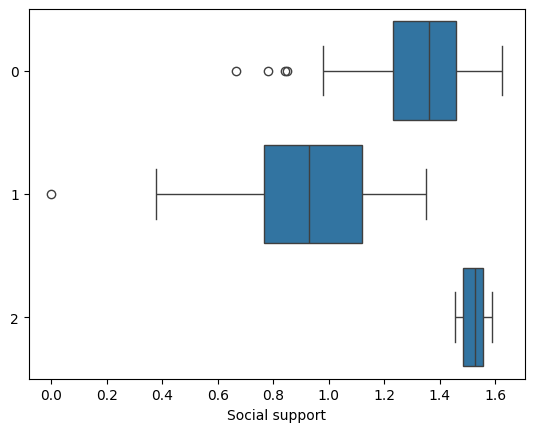

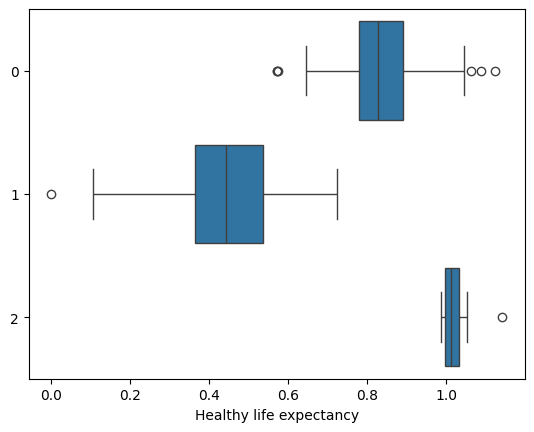

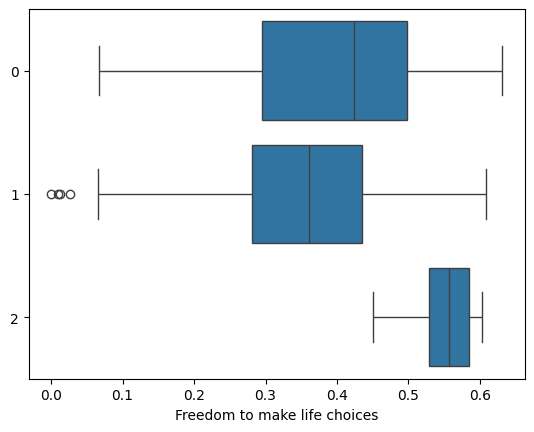

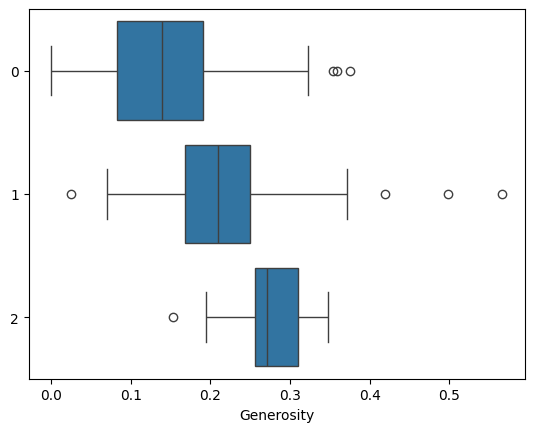

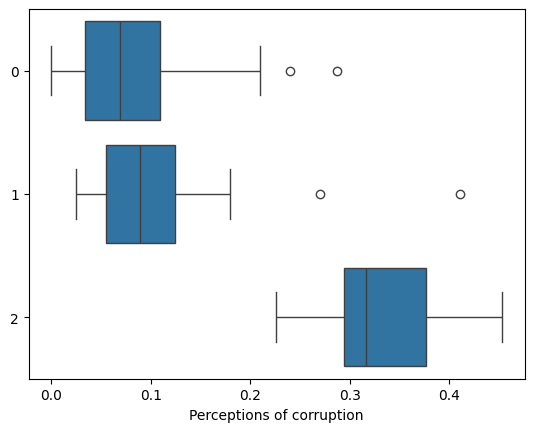

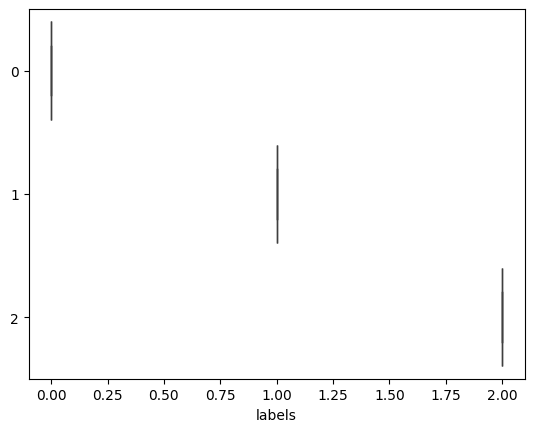

In [ ]:
for col in data.columns:
    sns.boxplot(data=data, x=col, y=labels, orient='h')
    plt.show();

In [ ]:
data.groupby('labels').median().T.round(2)

labels,0,1,2
Score,5.79,4.39,7.28
GDP per capita,1.06,0.39,1.38
Social support,1.36,0.93,1.53
Healthy life expectancy,0.83,0.44,1.01
Freedom to make life choices,0.42,0.36,0.56
Generosity,0.14,0.21,0.27
Perceptions of corruption,0.07,0.09,0.32


## 4.1 DBSCAN

100%|██████████| 90/90 [00:00<00:00, 222.19it/s]


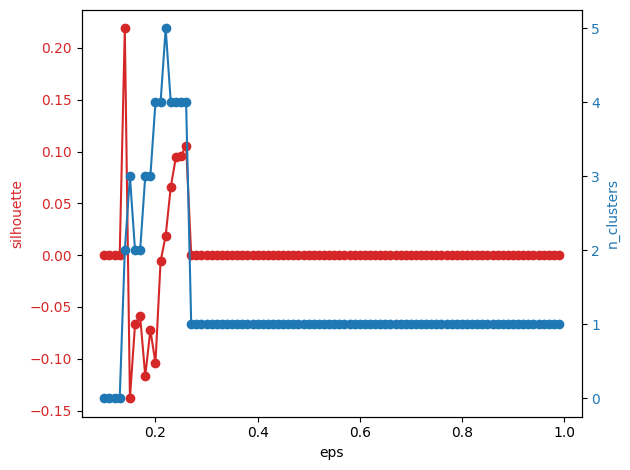

In [ ]:
eps_range = np.arange(0.1,1,0.01)
dbscan_clustering(eps_range, X_scaled)

100%|██████████| 31/31 [00:00<00:00, 199.76it/s]


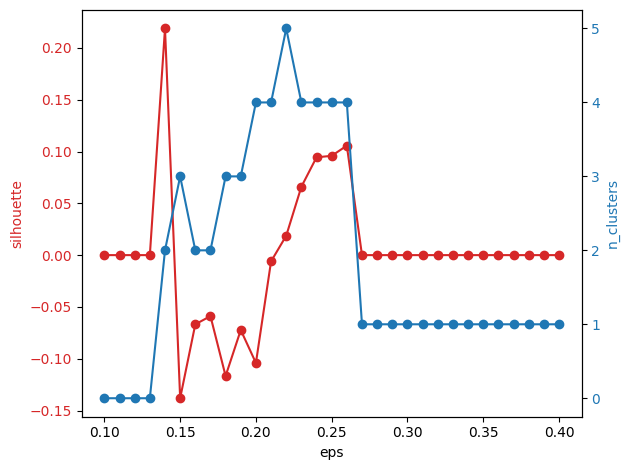

In [ ]:
eps_range = np.arange(0.1,0.4,0.01)
dbscan_clustering(eps_range, X_scaled)

100%|██████████| 20/20 [00:00<00:00, 203.56it/s]


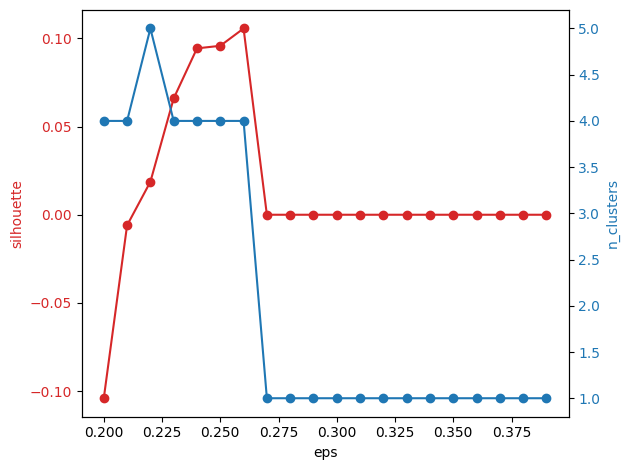

In [ ]:
eps_range = np.arange(0.2,0.4,0.01)
dbscan_clustering(eps_range, X_scaled)

100%|██████████| 6/6 [00:00<00:00, 144.23it/s]


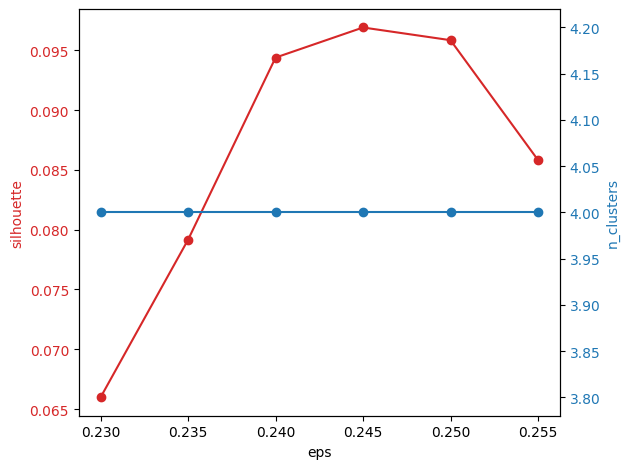

In [ ]:
eps_range = np.arange(0.23,0.26,0.005)
dbscan_clustering(eps_range, X_scaled)

In [ ]:
dbscan = DBSCAN(eps=0.245).fit(X_scaled)
labels = dbscan.labels_

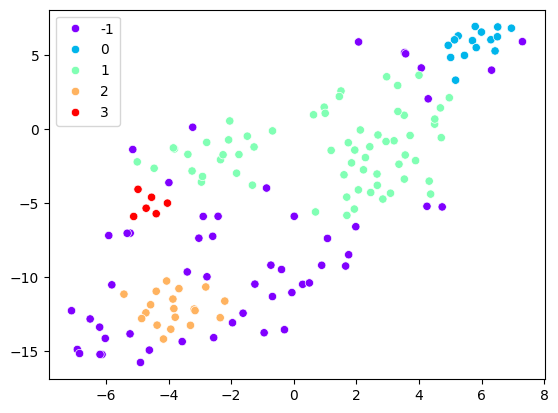

In [ ]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='rainbow');

In [ ]:
data['labels'] = labels

In [ ]:
data['labels'].value_counts(normalize=True)

,proportion
labels,
1,0.403846
-1,0.339744
2,0.121795
0,0.096154
3,0.038462


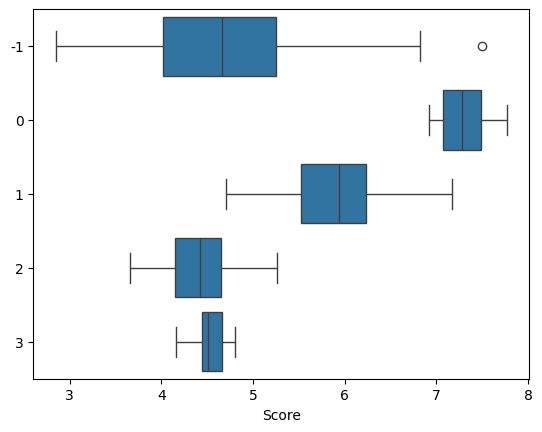

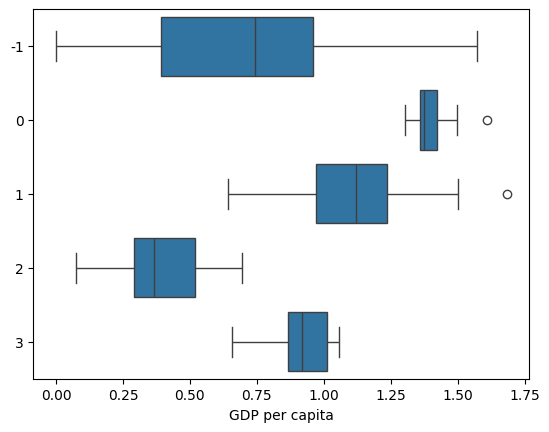

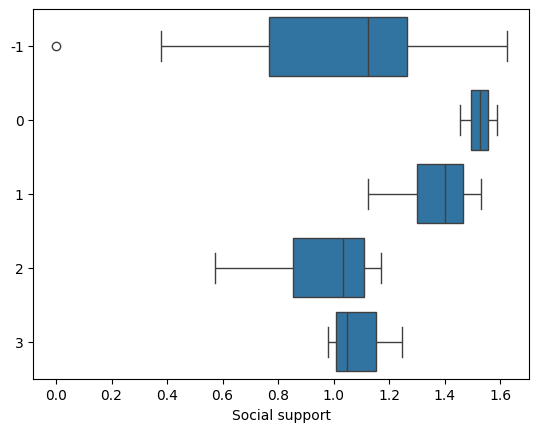

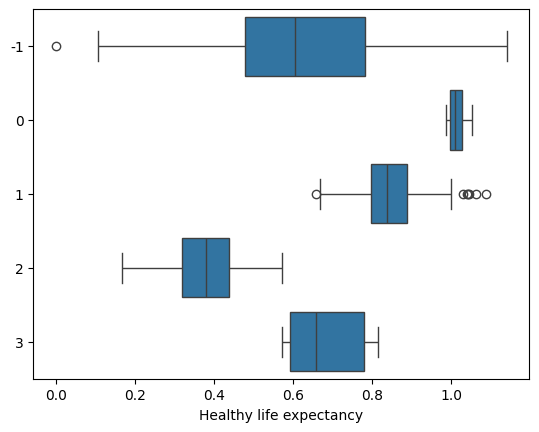

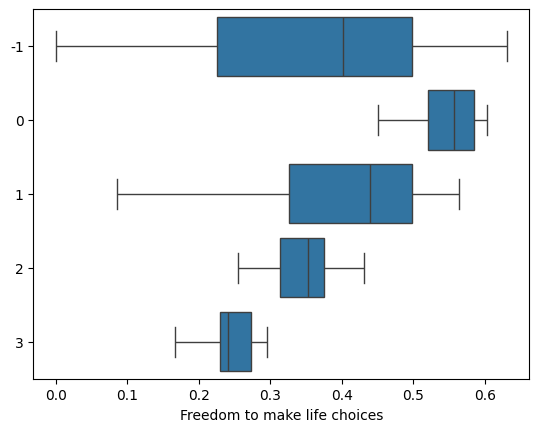

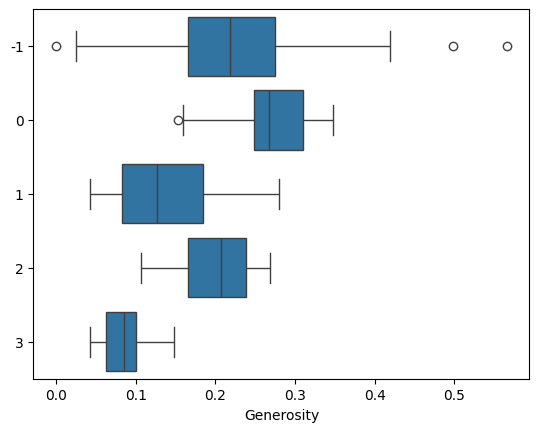

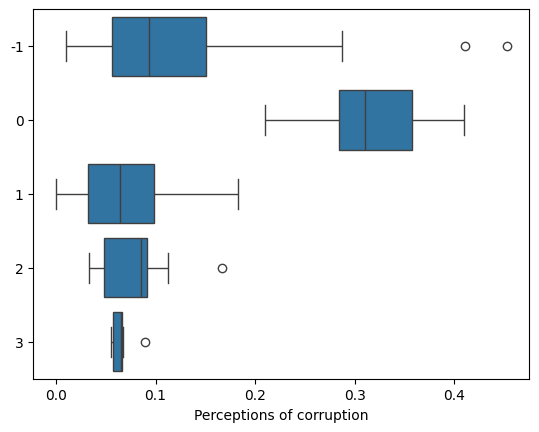

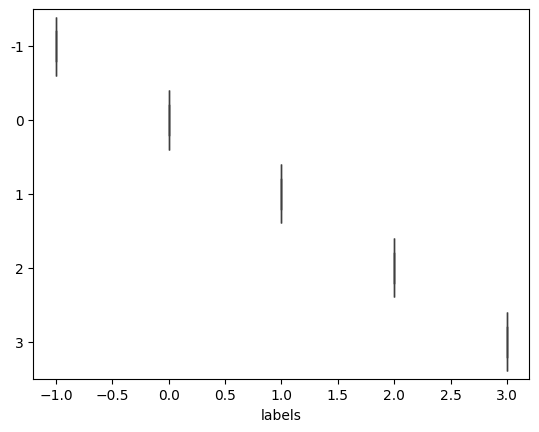

In [ ]:
for col in data.columns:
    sns.boxplot(data=data, x=col, y=labels, orient='h')
    plt.show();

In [ ]:
data.groupby('labels').median().T.round(2)

labels,-1,0,1,2,3
Score,4.67,7.28,5.94,4.42,4.51
GDP per capita,0.74,1.38,1.12,0.37,0.92
Social support,1.12,1.53,1.40,1.03,1.05
Healthy life expectancy,0.60,1.01,0.84,0.38,0.66
Freedom to make life choices,0.40,0.56,0.44,0.35,0.24
Generosity,0.22,0.27,0.13,0.21,0.09
Perceptions of corruption,0.09,0.31,0.06,0.08,0.06


In [ ]:
country

,Country or region
0,Finland
1,Denmark
2,Norway
3,Iceland
4,Netherlands
...,...
151,Rwanda
152,Tanzania
153,Afghanistan
154,Central African Republic


In [ ]:
country[data['labels'] == 0]

,Country or region
0,Finland
1,Denmark
2,Norway
4,Netherlands
5,Switzerland
6,Sweden
7,New Zealand
8,Canada
9,Austria
10,Australia
